In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.tables import (
    aggregate_global_summary,
    rank_algorithms_by_instance,
    pivot_metric,
)

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.tables import (
    aggregate_global_summary,
    rank_algorithms_by_instance,
    pivot_metric,
)

In [3]:
repo_root = Path.cwd().parent
summary_path = repo_root / "results" / "processed" / "variance_suite" / "global_summary.csv"

df = pd.read_csv(summary_path)
df.head()

,experiment_name,instance_name,algorithm_name,seed,T,gamma,u_star,final_utility,mean_utility,final_gap,...,final_w_2,final_w_3,w_star_0,w_star_1,w_star_2,w_star_3,final_w_4,w_star_4,final_w_5,w_star_5
0,variance_suite,beta_mixture_4,variance_mirror_ascent,101,500,0.02,0.101486,0.070036,0.068798,0.031450,...,0.240226,0.217436,0.48,0.48,0.02,0.02,NaN,NaN,NaN,NaN
1,variance_suite,beta_mixture_4,variance_mirror_ascent,202,500,0.02,0.101486,0.069503,0.068485,0.031983,...,0.237825,0.224177,0.48,0.48,0.02,0.02,NaN,NaN,NaN,NaN
2,variance_suite,beta_mixture_4,variance_mirror_ascent,303,500,0.02,0.101486,0.069802,0.068590,0.031684,...,0.237364,0.221381,0.48,0.48,0.02,0.02,NaN,NaN,NaN,NaN
3,variance_suite,beta_mixture_4,variance_mirror_ascent,404,500,0.02,0.101486,0.070046,0.068779,0.031440,...,0.238399,0.218335,0.48,0.48,0.02,0.02,NaN,NaN,NaN,NaN
4,variance_suite,beta_mixture_4,variance_mirror_ascent,505,500,0.02,0.101486,0.069803,0.068607,0.031682,...,0.242215,0.218695,0.48,0.48,0.02,0.02,NaN,NaN,NaN,NaN


In [4]:
agg_df = aggregate_global_summary(df)
agg_df

,instance_name,algorithm_name,mean_final_utility,std_final_utility,mean_final_gap,std_final_gap,mean_l1_error,std_l1_error,mean_mean_utility,mean_mean_gap,n_runs
0,beta_mixture_4,variance_mirror_ascent,0.069838,0.000222,0.031648,0.000222,0.838421,0.004408,0.068652,0.032834,5
1,beta_mixture_4,uniform,0.066297,0.000000,0.035188,0.000000,0.920000,0.000000,0.066297,0.035188,5
2,beta_shifted_5,variance_mirror_ascent,0.265313,0.005886,0.081670,0.005886,0.878016,0.041381,0.255325,0.091658,5
3,beta_shifted_5,uniform,0.235230,0.000000,0.111753,0.000000,1.080000,0.000000,0.235230,0.111753,5
4,mixed_shapes_6,variance_mirror_ascent,0.069707,0.000182,0.030424,0.000182,1.131876,0.003483,0.069094,0.031038,5
5,mixed_shapes_6,uniform,0.067765,0.000000,0.032367,0.000000,1.173333,0.000000,0.067765,0.032367,5
6,triangular_4,variance_mirror_ascent,0.141995,0.002740,0.059972,0.002740,0.746280,0.017831,0.132871,0.069096,5
7,triangular_4,uniform,0.117292,0.000000,0.084675,0.000000,0.920000,0.000000,0.117292,0.084675,5


In [5]:
rank_df = rank_algorithms_by_instance(df)
rank_df[[
    "instance_name",
    "algorithm_name",
    "mean_final_gap",
    "mean_l1_error",
    "rank_by_final_gap",
]]

,instance_name,algorithm_name,mean_final_gap,mean_l1_error,rank_by_final_gap
0,beta_mixture_4,variance_mirror_ascent,0.031648,0.838421,1
1,beta_mixture_4,uniform,0.035188,0.920000,2
2,beta_shifted_5,variance_mirror_ascent,0.081670,0.878016,1
3,beta_shifted_5,uniform,0.111753,1.080000,2
4,mixed_shapes_6,variance_mirror_ascent,0.030424,1.131876,1
5,mixed_shapes_6,uniform,0.032367,1.173333,2
6,triangular_4,variance_mirror_ascent,0.059972,0.746280,1
7,triangular_4,uniform,0.084675,0.920000,2


In [6]:
pivot_gap = pivot_metric(rank_df, "mean_final_gap")
pivot_gap

algorithm_name,uniform,variance_mirror_ascent
instance_name,,
beta_mixture_4,0.035188,0.031648
beta_shifted_5,0.111753,0.081670
mixed_shapes_6,0.032367,0.030424
triangular_4,0.084675,0.059972


In [8]:
pivot_l1 = pivot_metric(rank_df, "mean_l1_error")
pivot_l1

algorithm_name,uniform,variance_mirror_ascent
instance_name,,
beta_mixture_4,0.920000,0.838421
beta_shifted_5,1.080000,0.878016
mixed_shapes_6,1.173333,1.131876
triangular_4,0.920000,0.746280


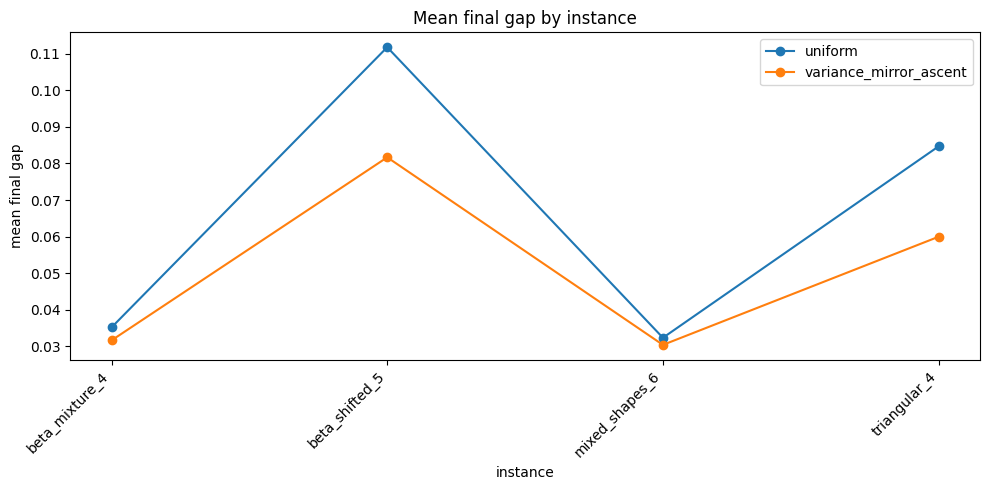

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

for algorithm_name, subdf in rank_df.groupby("algorithm_name"):
    ax.plot(
        subdf["instance_name"],
        subdf["mean_final_gap"],
        marker="o",
        label=algorithm_name,
    )

ax.set_xlabel("instance")
ax.set_ylabel("mean final gap")
ax.set_title("Mean final gap by instance")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

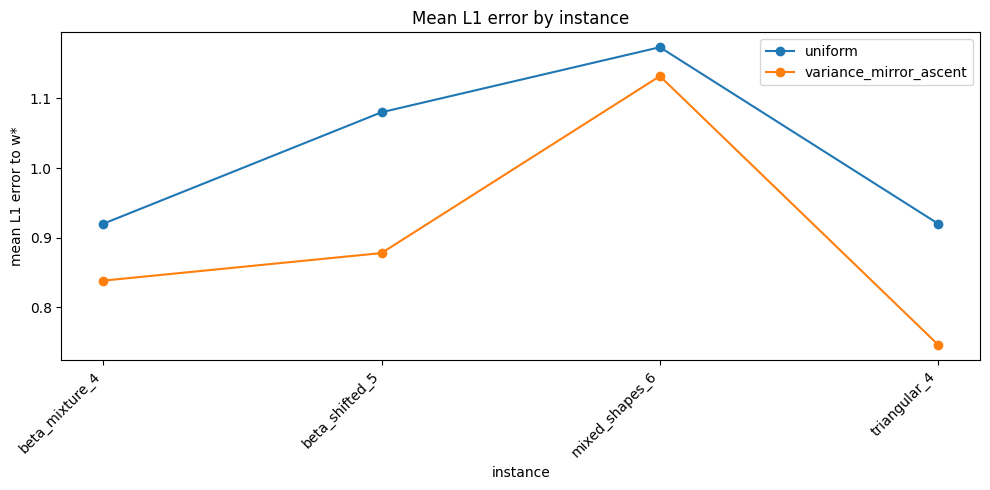

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for algorithm_name, subdf in rank_df.groupby("algorithm_name"):
    ax.plot(
        subdf["instance_name"],
        subdf["mean_l1_error"],
        marker="o",
        label=algorithm_name,
    )

ax.set_xlabel("instance")
ax.set_ylabel("mean L1 error to w*")
ax.set_title("Mean L1 error by instance")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [11]:
output_dir = repo_root / "results" / "processed" / "variance_suite"

agg_df.to_csv(output_dir / "aggregated_summary.csv", index=False)
rank_df.to_csv(output_dir / "ranked_summary.csv", index=False)
pivot_gap.to_csv(output_dir / "pivot_final_gap.csv")
pivot_l1.to_csv(output_dir / "pivot_l1_error.csv")

print("Saved aggregated tables.")

Saved aggregated tables.
